# Performance Profiling

This notebook profiles the four core pipeline stages of the F&B location analytics system:

| Part | Stage                        | Key functions                                                 |
| ------| ------------------------------| ---------------------------------------------------------------|
| 1    | Data loading & preprocessing | `pd.read_csv`, `build_analysis_df`                            |
| 2    | Pareto front computation     | `pareto_efficient_mask`, `run_pareto`                         |
| 3    | KMeans clustering            | `build_cluster_lookup`, `KMeans.fit_predict`                  |
| 4    | End-to-end pipeline          | full `main()` equivalent                                      |uery-side latency |

Profiling tools used:
- `cProfile` + `pstats`: function-level CPU hotspot analysis
- `timeit`: micro-benchmarking isolated operations
- `time.perf_counter`: wall-clock timing with N repetitions
- `tracemalloc`: heap memory delta tracking
- `matplotlib`: side-by-side comparison plots

## Setup

In [3]:
import cProfile
import io
import pstats
import timeit
import tracemalloc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"sklearn imported OK")

pandas  3.0.2
numpy   2.4.4
sklearn imported OK


In [4]:
ROOT = Path(".").resolve()
MASTER_CSV = ROOT / "master_dataset.csv"

assert MASTER_CSV.exists(), f"master_dataset.csv not found at {MASTER_CSV}"
print(f"Dataset path : {MASTER_CSV}")

_df_check = pd.read_csv(MASTER_CSV)
print(f"Rows: {len(_df_check)} | Columns: {len(_df_check.columns)}")

Dataset path : /home/User/Documents/IS5126/fnb-analytics/master_dataset.csv
Rows: 50 | Columns: 54


In [8]:
# Profiling helpers

N_REPS = 20  # repetitions for wall-clock timing


def run_cprofile(func, *args, top_n: int = 15, sort_by: str = "cumulative", **kwargs) -> str:
    """Run cProfile on func(*args, **kwargs), return formatted stats string."""
    pr = cProfile.Profile()
    pr.enable()
    func(*args, **kwargs)
    pr.disable()
    buf = io.StringIO()
    ps = pstats.Stats(pr, stream=buf).sort_stats(sort_by)
    ps.print_stats(top_n)
    return buf.getvalue()


def measure_memory(func, *args, **kwargs) -> tuple[float, float]:
    """Return (peak_kb, delta_kb) for a single call of func(*args, **kwargs)."""
    tracemalloc.start()
    func(*args, **kwargs)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024, (peak - current) / 1024


def time_call(func, *args, n: int = N_REPS, **kwargs) -> dict:
    """Execute func n times, return timing stats dict (ms)."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func(*args, **kwargs)
        times.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times)
    return {
        "min": arr.min(),
        "mean": arr.mean(),
        "median": np.median(arr),
        "p95": np.percentile(arr, 95),
        "max": arr.max(),
        "std": arr.std(),
        "n": n,
    }


def print_timing(label: str, stats: dict) -> None:
    print(
        f"{label:<38s}  "
        f"min={stats['min']:7.2f}ms  "
        f"mean={stats['mean']:7.2f}ms  "
        f"median={stats['median']:7.2f}ms  "
        f"p95={stats['p95']:7.2f}ms  "
        f"(n={stats['n']})"
    )


print("Helpers ready.")

Helpers ready.


---
## Part 1: Data Loading & Preprocessing

Three loading strategies are benchmarked:

| Strategy     | Description                                                     |
| --------------| -----------------------------------------------------------------|
| `full`       | `pd.read_csv` with no arguments: baseline                      |
| `projection` | Read only the columns actually used in analysis                 |
| `typed`      | Full read with explicit `dtype` map to avoid inference overhead |

In [69]:
# Columns consumed by build_analysis_df and downstream Pareto / clustering steps
ANALYSIS_COLS = [
    "PLANNING_AREA", "total_footfall", "total_inflow",
    "weekday_volume", "weekend_volume",
    "morning", "lunch", "evening", "afternoon", "other",
    "low_income", "mid_income", "high_income",
    "children", "teens_youth", "young_adults",
    "mid_age_adults", "older_adults", "seniors",
    "competitor_count", "unique_category_count",
    "mean_rating", "mean_price_mid",
    "hawker_stall_count", "restaurant_count",
    "chinese_count", "japanese_count", "indian_count",
    "cafe_count", "thai_count", "fast_food_count",
    "inflow_ratio", "rent_proxy_psm",
]

INT_COLS = [
    "total_footfall", "total_inflow", "weekday_volume", "weekend_volume",
    "morning", "lunch", "evening", "afternoon", "other",
    "competitor_count", "unique_category_count",
    "hawker_stall_count", "restaurant_count",
    "chinese_count", "japanese_count", "indian_count",
    "cafe_count", "thai_count", "fast_food_count",
]
FLOAT_COLS = [
    "low_income", "mid_income", "high_income",
    "children", "teens_youth", "young_adults",
    "mid_age_adults", "older_adults", "seniors",
    "mean_rating", "mean_price_mid", "inflow_ratio", "rent_proxy_psm",
]
DTYPE_MAP = {col: "Int64" for col in INT_COLS}
DTYPE_MAP.update({col: "float64" for col in FLOAT_COLS})


def load_full():
    return pd.read_csv(MASTER_CSV)


def load_projection():
    return pd.read_csv(MASTER_CSV, usecols=ANALYSIS_COLS)


def load_typed():
    return pd.read_csv(MASTER_CSV, dtype=DTYPE_MAP)


print("Loading strategy functions defined.")

Loading strategy functions defined.


In [70]:
# Benchmark loading strategies
load_stats = {}
for label, fn in [("full", load_full), ("projection", load_projection), ("typed", load_typed)]:
    load_stats[label] = time_call(fn)
    print_timing(f"load_{label}", load_stats[label])

load_full                                 min=   1.10ms  mean=   1.52ms  median=   1.37ms  p95=   2.24ms  (n=20)
load_projection                           min=   0.81ms  mean=   1.01ms  median=   0.92ms  p95=   1.48ms  (n=20)
load_typed                                min=   3.76ms  mean=   4.31ms  median=   4.23ms  p95=   5.14ms  (n=20)


In [71]:
# Memory: loading strategies
load_mem = {}
for label, fn in [("full", load_full), ("projection", load_projection), ("typed", load_typed)]:
    peak_kb, _ = measure_memory(fn)
    load_mem[label] = peak_kb
    print(f"load_{label:<12s}  peak={peak_kb:8.1f} KB")

load_full          peak=   295.6 KB
load_projection    peak=   296.6 KB
load_typed         peak=   296.8 KB


In [72]:
# build_analysis_df: profiled
def build_analysis_df(df: pd.DataFrame) -> pd.DataFrame:
    """Replicated from build_pareto_map_data_updated.py."""
    out = df.copy()
    out["log_footfall"] = np.log1p(out["total_footfall"])

    total_day = out["weekday_volume"] + out["weekend_volume"]
    out["weekday_ratio"] = out["weekday_volume"] / total_day
    out["weekend_ratio"] = out["weekend_volume"] / total_day

    time_cols = ["morning", "lunch", "evening", "afternoon", "other"]
    out[[f"{c}_ratio" for c in time_cols]] = out[time_cols].div(
        out[time_cols].sum(axis=1), axis=0
    )

    income_cols = ["low_income", "mid_income", "high_income"]
    out["income_total"] = out[income_cols].sum(axis=1, min_count=1)
    for col in income_cols:
        out[f"{col}_ratio"] = out[col] / out["income_total"]

    demo_cols = ["children", "teens_youth", "young_adults", "mid_age_adults", "older_adults", "seniors"]
    out["demo_total"] = out[demo_cols].sum(axis=1, min_count=1)
    for col in demo_cols:
        out[f"{col}_ratio"] = out[col] / out["demo_total"]

    out["log_competitor_count"] = np.log1p(out["competitor_count"])

    comp_cols = ["hawker_stall_count", "restaurant_count", "chinese_count",
                 "japanese_count", "indian_count", "cafe_count", "thai_count", "fast_food_count"]
    for col in comp_cols:
        out[f"{col}_ratio"] = out[col] / out["competitor_count"]

    return out


_raw_df = load_full()
print("cProfile: build_analysis_df")
print("=" * 60)
profile_text = run_cprofile(build_analysis_df, _raw_df)
print(profile_text)


cProfile: build_analysis_df
         32682 function calls (32335 primitive calls) in 0.018 seconds

   Ordered by: cumulative time
   List reduced from 532 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    30/24    0.000    0.000    0.007    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4559(__setitem__)
    29/28    0.000    0.000    0.007    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4862(_set_item)
    29/28    0.000    0.000    0.006    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4846(_set_item_mgr)
    29/28    0.000    0.000    0.006    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1523(insert)
       49    0.000    0.000    0.005    0.000 /home/User/Documents/IS5126/fnb-analyti

In [73]:
# build_analysis_df: timing & memory
analysis_stats = time_call(build_analysis_df, _raw_df)
print_timing("build_analysis_df", analysis_stats)

analysis_peak_kb, _ = measure_memory(build_analysis_df, _raw_df)
print(f"build_analysis_df  peak memory = {analysis_peak_kb:.1f} KB")

build_analysis_df                         min=   7.68ms  mean=   9.07ms  median=   8.45ms  p95=  11.39ms  (n=20)
build_analysis_df  peak memory = 96.0 KB


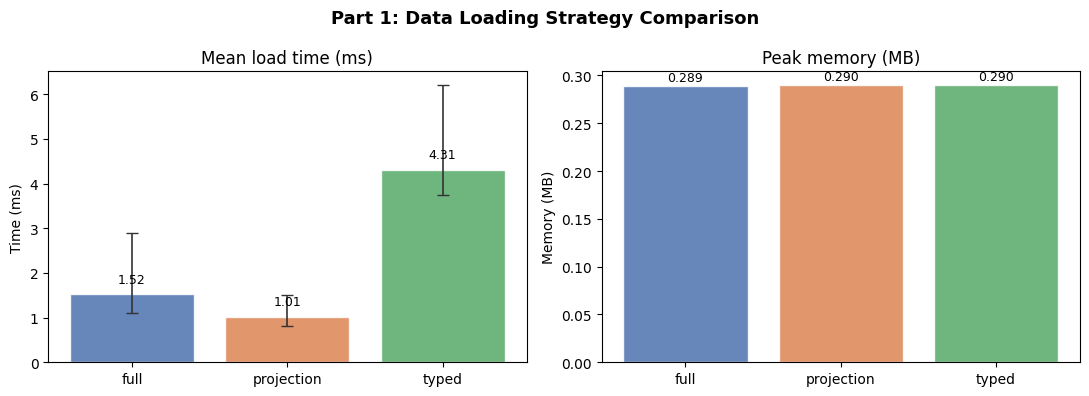

In [ ]:
# Plot: loading strategies: mean time & peak memory
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Part 1: Data Loading Strategy Comparison", fontsize=13, fontweight="bold")

labels = list(load_stats.keys())
means  = [load_stats[l]["mean"]   for l in labels]
p95s   = [load_stats[l]["p95"]    for l in labels]
mems   = [load_mem[l] / 1024      for l in labels]  # -> MB
colours = ["#4C72B0", "#DD8452", "#55A868"]

# Mean time
bars = axes[0].bar(labels, means, color=colours, alpha=0.85, edgecolor="white")
axes[0].errorbar(labels, means,
                 yerr=[np.array(means) - [load_stats[l]["min"] for l in labels],
                       [load_stats[l]["max"] for l in labels] - np.array(means)],
                 fmt="none", color="#333", capsize=4, linewidth=1.2)
axes[0].set_title("Mean load time (ms)")
axes[0].set_ylabel("Time (ms)")
for bar, v in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.2, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=9)

# Peak memory
bars2 = axes[1].bar(labels, mems, color=colours, alpha=0.85, edgecolor="white")
axes[1].set_title("Peak memory (MB)")
axes[1].set_ylabel("Memory (MB)")
for bar, v in zip(bars2, mems):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.002, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 2: Pareto Algorithm Profiling

The Pareto front is computed by `pareto_efficient_mask`, a nested-loop algorithm with O(n²) worst-case complexity.
Three implementations are compared:

| Variant | Description |
|---------|-------------|
| `loop` | Baseline: original row-by-row loop |
| `vectorized` | Fully NumPy-vectorized dominance check |
| `early_exit` | Loop with early termination once dominated |

Each is benchmarked at the real dataset size (n ≈ 50) and at synthetic scaled sizes.

In [75]:
# Pareto implementations

def pareto_loop(values: np.ndarray) -> np.ndarray:
    """Original loop-based implementation (from build_pareto_map_data_updated.py)."""
    n = values.shape[0]
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        dominates_i = np.all(values >= values[i], axis=1) & np.any(values > values[i], axis=1)
        dominates_i[i] = False
        if np.any(dominates_i):
            is_efficient[i] = False
    return is_efficient


def pareto_vectorized(values: np.ndarray) -> np.ndarray:
    """Fully vectorized: broadcast (n,1,d) vs (1,n,d) for all pairs at once."""
    v = values[:, np.newaxis, :]          # (n, 1, d)
    u = values[np.newaxis, :, :]          # (1, n, d)
    dominated = (
        np.all(u >= v, axis=2) &          # every dim of u >= v
        np.any(u > v, axis=2)             # at least one dim strictly greater
    )                                     # dominated[i, j] = True iff j dominates i
    np.fill_diagonal(dominated, False)
    return ~dominated.any(axis=1)


def pareto_early_exit(values: np.ndarray) -> np.ndarray:
    """Loop with early exit once a dominator is found for row i."""
    n = values.shape[0]
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        for j in range(n):
            if i == j or not is_efficient[j]:
                continue
            if np.all(values[j] >= values[i]) and np.any(values[j] > values[i]):
                is_efficient[i] = False
                break
    return is_efficient


print("Pareto implementations defined.")

Pareto implementations defined.


In [76]:
# Correctness check: all three must agree
rng = np.random.default_rng(42)
test_vals = rng.random((50, 5))

r_loop = pareto_loop(test_vals)
r_vec  = pareto_vectorized(test_vals)
r_exit = pareto_early_exit(test_vals)

assert np.array_equal(r_loop, r_vec),  "loop vs vectorized mismatch!"
assert np.array_equal(r_loop, r_exit), "loop vs early_exit mismatch!"
print(f"All three implementations agree on n=50.  Pareto-efficient rows: {r_loop.sum()}/50")

All three implementations agree on n=50.  Pareto-efficient rows: 28/50


In [77]:
# Benchmark at real dataset size (n ≈ 50)
_analysis_df = build_analysis_df(_raw_df)

# Use the affordable concept columns as a representative 5-dim Pareto problem
_pareto_cols = ["log_footfall", "low_income_ratio", "mid_income_ratio",
                "hawker_stall_count_ratio", "neg_mean_price_mid"]
_pareto_base = _analysis_df.copy()
_pareto_base["neg_mean_price_mid"] = -_pareto_base["mean_price_mid"]
_pareto_vals = _pareto_base[_pareto_cols].dropna().to_numpy()

print(f"Pareto input shape: {_pareto_vals.shape}")
pareto_real_stats = {}
for label, fn in [("loop", pareto_loop), ("vectorized", pareto_vectorized), ("early_exit", pareto_early_exit)]:
    pareto_real_stats[label] = time_call(fn, _pareto_vals)
    print_timing(f"pareto_{label}", pareto_real_stats[label])

Pareto input shape: (30, 5)
pareto_loop                               min=   0.28ms  mean=   0.32ms  median=   0.30ms  p95=   0.39ms  (n=20)
pareto_vectorized                         min=   0.02ms  mean=   0.06ms  median=   0.02ms  p95=   0.26ms  (n=20)
pareto_early_exit                         min=   1.03ms  mean=   1.36ms  median=   1.24ms  p95=   2.05ms  (n=20)


In [78]:
# Benchmark at scaled sizes: n = 50, 200, 500, 1000, 5000
sizes = [50, 200, 500, 1_000, 5_000]
scaled_results = {label: [] for label in ["loop", "vectorized", "early_exit"]}

rng = np.random.default_rng(0)
for n in sizes:
    vals = rng.random((n, 5))
    for label, fn in [("loop", pareto_loop), ("vectorized", pareto_vectorized), ("early_exit", pareto_early_exit)]:
        # Fewer reps for large n to keep runtime reasonable
        reps = max(3, N_REPS // (n // 50))
        s = time_call(fn, vals, n=reps)
        scaled_results[label].append(s["mean"])
    print(f"n={n:<5d}  done")

n=50     done
n=200    done
n=500    done
n=1000   done
n=5000   done


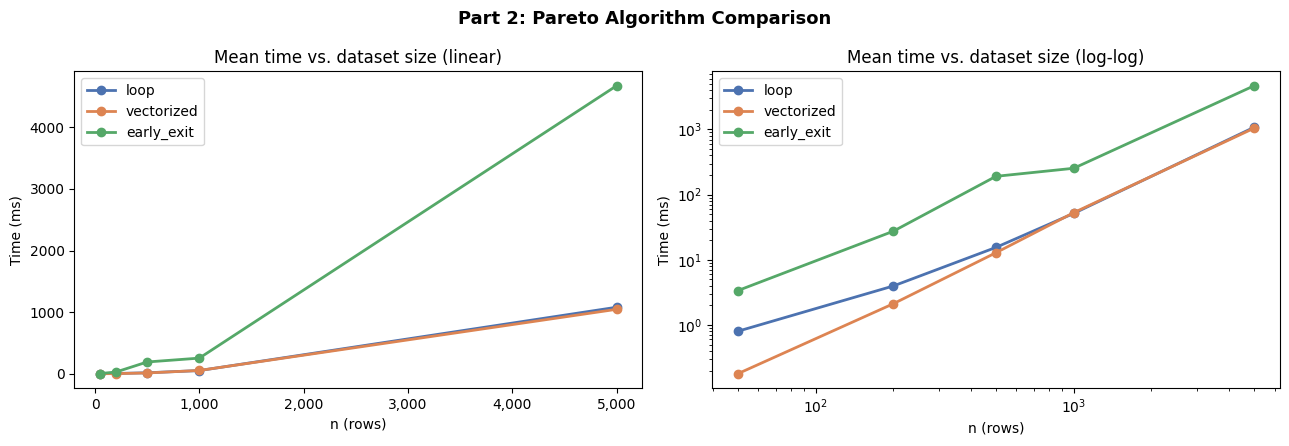

In [79]:
# Plot: Pareto scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Part 2: Pareto Algorithm Comparison", fontsize=13, fontweight="bold")

colours = {"loop": "#4C72B0", "vectorized": "#DD8452", "early_exit": "#55A868"}

# Linear scale
for label, vals in scaled_results.items():
    axes[0].plot(sizes, vals, marker="o", label=label, color=colours[label], linewidth=2)
axes[0].set_title("Mean time vs. dataset size (linear)")
axes[0].set_xlabel("n (rows)")
axes[0].set_ylabel("Time (ms)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Log-log scale to reveal complexity class
for label, vals in scaled_results.items():
    axes[1].loglog(sizes, vals, marker="o", label=label, color=colours[label], linewidth=2)
axes[1].set_title("Mean time vs. dataset size (log-log)")
axes[1].set_xlabel("n (rows)")
axes[1].set_ylabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [80]:
# run_pareto: per-concept timing across all 5 concepts
SPECIAL_CASE_AREAS = {
    "CENTRAL WATER CATCHMENT", "LIM CHU KANG",
    "MARINA SOUTH", "SOUTHERN ISLANDS", "STRAITS VIEW",
}

CONCEPTS = {
    "affordable_everyday_meal": {
        "maximize": ["log_footfall", "low_income_ratio", "mid_income_ratio", "hawker_stall_count_ratio"],
        "minimize": ["mean_price_mid"],
    },
    "premium_cafe": {
        "maximize": ["mean_price_mid", "high_income_ratio", "unique_category_count", "mean_rating"],
        "minimize": [],
    },
    "family_casual_dining": {
        "maximize": ["children_ratio", "mid_age_adults_ratio", "weekend_ratio", "mid_income_ratio"],
        "minimize": ["mean_price_mid", "log_competitor_count"],
    },
    "local_cuisine": {
        "maximize": ["chinese_count_ratio", "indian_count_ratio", "hawker_stall_count_ratio"],
        "minimize": ["cafe_count_ratio"],
    },
    "fast_food_grab_go": {
        "maximize": ["log_footfall", "weekday_ratio", "fast_food_count_ratio", "teens_youth_ratio"],
        "minimize": ["mean_price_mid"],
    },
}


def run_pareto(df: pd.DataFrame, concept_config: dict) -> pd.DataFrame:
    maximize_cols = concept_config["maximize"]
    minimize_cols = concept_config["minimize"]
    needed = ["PLANNING_AREA", *maximize_cols, *minimize_cols]
    cdf = df[needed].dropna(subset=maximize_cols + minimize_cols).reset_index(drop=True)
    for col in minimize_cols:
        cdf[f"neg_{col}"] = -cdf[col]
    pareto_cols = maximize_cols + [f"neg_{col}" for col in minimize_cols]
    mask = pareto_loop(cdf[pareto_cols].to_numpy())
    return cdf[mask].copy()


concept_stats = {}
for concept_key, cfg in CONCEPTS.items():
    concept_stats[concept_key] = time_call(run_pareto, _analysis_df, cfg)
    print_timing(concept_key[:30], concept_stats[concept_key])

affordable_everyday_meal                  min=   1.77ms  mean=   2.15ms  median=   1.94ms  p95=   3.10ms  (n=20)
premium_cafe                              min=   1.54ms  mean=   1.88ms  median=   1.78ms  p95=   2.53ms  (n=20)
family_casual_dining                      min=   1.90ms  mean=   2.11ms  median=   2.07ms  p95=   2.52ms  (n=20)
local_cuisine                             min=   1.70ms  mean=   1.83ms  median=   1.80ms  p95=   1.93ms  (n=20)
fast_food_grab_go                         min=   1.83ms  mean=   2.00ms  median=   1.90ms  p95=   2.40ms  (n=20)


In [81]:
# cProfile: run_pareto (affordable concept)
affordable_cfg = CONCEPTS["affordable_everyday_meal"]
print("cProfile: run_pareto (affordable_everyday_meal)")
print("=" * 60)
profile_text = run_cprofile(run_pareto, _analysis_df, affordable_cfg)
print(profile_text)

cProfile: run_pareto (affordable_everyday_meal)
         5071 function calls (4974 primitive calls) in 0.004 seconds

   Ordered by: cumulative time
   List reduced from 380 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.004    0.004 /tmp/ipykernel_297803/3000215116.py:31(run_pareto)
        4    0.000    0.000    0.002    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4337(__getitem__)
        1    0.000    0.000    0.001    0.001 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:7654(dropna)
        5    0.000    0.000    0.001    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/generic.py:4010(take)
        5    0.000    0.000    0.001    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/internals/manag

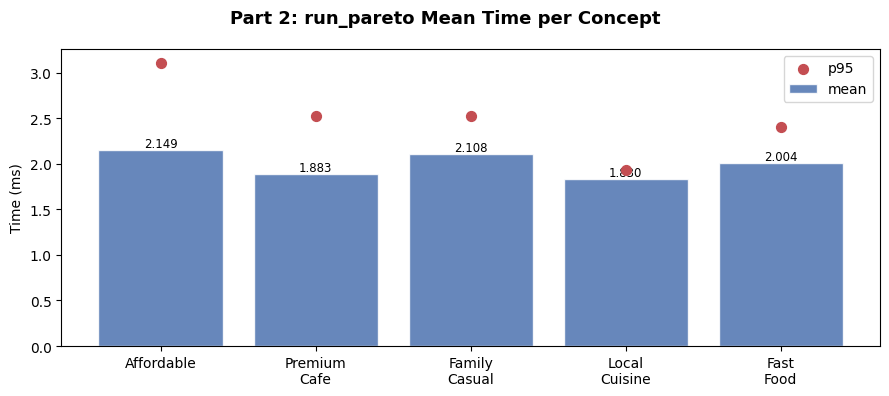

In [82]:
# Plot: per-concept run_pareto timing
short_labels = [
    "Affordable", "Premium\nCafe", "Family\nCasual", "Local\nCuisine", "Fast\nFood"
]
means_ms = [concept_stats[k]["mean"] for k in CONCEPTS]
p95_ms   = [concept_stats[k]["p95"]  for k in CONCEPTS]

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Part 2: run_pareto Mean Time per Concept", fontsize=13, fontweight="bold")
bars = ax.bar(short_labels, means_ms, color="#4C72B0", alpha=0.85, edgecolor="white", label="mean")
ax.scatter(short_labels, p95_ms, color="#C44E52", zorder=5, label="p95", s=50)
ax.set_ylabel("Time (ms)")
ax.legend()
for bar, v in zip(bars, means_ms):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001, f"{v:.3f}",
            ha="center", va="bottom", fontsize=8.5)
plt.tight_layout()
plt.show()

---
## Part 3: KMeans Clustering Profiling

The production `build_cluster_lookup` now persists the fitted `SimpleImputer`, `StandardScaler`, and `KMeans` objects
to `.cluster_cache.joblib` and invalidates the cache via a SHA-256 hash of `master_dataset.csv`.

Four sub-sections:

1. **Cold vs. warm**: benchmark a forced cache-miss (fit) against a cache-hit (load + transform)
2. **k sweep**: cold-path time across k = 2 … 10 with `n_init=20`
3. **n_init sensitivity**: cold-path time for k=3 at varying `n_init`
4. **cProfile + memory**: hotspot and heap analysis for both cold and warm paths

In [83]:
import hashlib
import joblib

CLUSTER_CACHE = ROOT / ".cluster_cache.joblib"

CLUSTERING_FEATURE_COLS = [
    "log_footfall", "inflow_ratio", "weekday_ratio",
    "morning_ratio", "lunch_ratio", "afternoon_ratio", "evening_ratio",
    "mid_income_ratio", "high_income_ratio",
    "children_ratio", "young_adults_ratio", "mid_age_adults_ratio", "seniors_ratio",
    "log_competitor_count", "unique_category_count",
    "mean_rating", "mean_price_mid",
    "hawker_stall_count_ratio", "restaurant_count_ratio",
    "cafe_count_ratio", "fast_food_count_ratio",
]

SPECIAL_CASE_AREAS = {
    "CENTRAL WATER CATCHMENT", "LIM CHU KANG",
    "MARINA SOUTH", "SOUTHERN ISLANDS", "STRAITS VIEW",
}

CLUSTER_METADATA = {
    0: {"label": "Mainstream Urban / Heartland",
        "description": "supports stronger everyday demand, denser competition, and a more mass-market, affordable environment."},
    1: {"label": "Peripheral / Low-Intensity",
        "description": "points to sparser commercial ecosystems and weaker overall F&B density."},
    2: {"label": "Premium Central / Lifestyle",
        "description": "supports higher price points, stronger ratings, and greater category diversity."},
}

def _dataset_hash() -> str:
    h = hashlib.sha256()
    h.update(MASTER_CSV.read_bytes())
    return h.hexdigest()

def _fit_clustering_models(x_train: pd.DataFrame):
    imputer = SimpleImputer(strategy="median")
    x_train_imp = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_imp)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
    kmeans.fit(x_train_scaled)
    return imputer, scaler, kmeans

def _get_train_pred_frames(analysis_df: pd.DataFrame):
    all_cols = ["PLANNING_AREA"] + CLUSTERING_FEATURE_COLS
    clustering_df = analysis_df[all_cols].copy()
    train_df = clustering_df[~clustering_df["PLANNING_AREA"].isin(SPECIAL_CASE_AREAS)].copy()
    pred_df  = clustering_df.copy()
    x_train  = train_df.drop(columns=["PLANNING_AREA"]).copy()
    x_all    = pred_df.drop(columns=["PLANNING_AREA"]).copy()
    return pred_df, x_train, x_all

def build_cluster_lookup_cold(analysis_df: pd.DataFrame) -> dict:
    """Always re-fits: simulates a cache miss."""
    pred_df, x_train, x_all = _get_train_pred_frames(analysis_df)
    train_names = pred_df[~pred_df["PLANNING_AREA"].isin(SPECIAL_CASE_AREAS)]["PLANNING_AREA"].copy()
    imputer, scaler, kmeans = _fit_clustering_models(x_train)
    joblib.dump(
        {"dataset_hash": _dataset_hash(), "imputer": imputer, "scaler": scaler, "kmeans": kmeans},
        CLUSTER_CACHE,
    )
    x_all_imp    = pd.DataFrame(imputer.transform(x_all), columns=x_all.columns, index=x_all.index)
    x_all_scaled = scaler.transform(x_all_imp)
    all_labels   = kmeans.predict(x_all_scaled)
    return dict(zip(pred_df["PLANNING_AREA"], all_labels.tolist()))

def build_cluster_lookup_warm(analysis_df: pd.DataFrame) -> dict:
    """Always loads from cache: simulates a cache hit (cache must exist)."""
    pred_df, x_train, x_all = _get_train_pred_frames(analysis_df)
    cached   = joblib.load(CLUSTER_CACHE)
    imputer  = cached["imputer"]
    scaler   = cached["scaler"]
    kmeans   = cached["kmeans"]
    x_all_imp    = pd.DataFrame(imputer.transform(x_all), columns=x_all.columns, index=x_all.index)
    x_all_scaled = scaler.transform(x_all_imp)
    all_labels   = kmeans.predict(x_all_scaled)
    return dict(zip(pred_df["PLANNING_AREA"], all_labels.tolist()))

# Pre-compute analysis_df once
_raw_df     = load_full()
_analysis_df = build_analysis_df(_raw_df)

# Ensure a valid cache exists before warm benchmarks
build_cluster_lookup_cold(_analysis_df)
print("Setup complete: cache primed at", CLUSTER_CACHE)

def build_cluster_lookup(analysis_df: pd.DataFrame) -> dict:
    """Production version: loads from cache if hash matches, otherwise fits and saves."""
    pred_df, x_train, x_all = _get_train_pred_frames(analysis_df)
    train_names = pred_df[~pred_df["PLANNING_AREA"].isin(SPECIAL_CASE_AREAS)]["PLANNING_AREA"].copy()
    current_hash = _dataset_hash()
    if CLUSTER_CACHE.exists():
        cached = joblib.load(CLUSTER_CACHE)
        if cached.get("dataset_hash") == current_hash:
            imputer, scaler, kmeans = cached["imputer"], cached["scaler"], cached["kmeans"]
        else:
            imputer, scaler, kmeans = _fit_clustering_models(x_train)
            joblib.dump({"dataset_hash": current_hash, "imputer": imputer, "scaler": scaler, "kmeans": kmeans}, CLUSTER_CACHE)
    else:
        imputer, scaler, kmeans = _fit_clustering_models(x_train)
        joblib.dump({"dataset_hash": current_hash, "imputer": imputer, "scaler": scaler, "kmeans": kmeans}, CLUSTER_CACHE)
    x_all_imp    = pd.DataFrame(imputer.transform(x_all), columns=x_all.columns, index=x_all.index)
    x_all_scaled = scaler.transform(x_all_imp)
    all_labels   = kmeans.predict(x_all_scaled)
    return dict(zip(pred_df["PLANNING_AREA"], all_labels.tolist()))


Setup complete: cache primed at /home/User/Documents/IS5126/fnb-analytics/.cluster_cache.joblib


In [129]:
# Cold vs. warm: head-to-head timing
cold_stats = time_call(build_cluster_lookup_cold, _analysis_df)
warm_stats = time_call(build_cluster_lookup_warm, _analysis_df)

print_timing("build_cluster_lookup  COLD (fit)",        cold_stats)
print_timing("build_cluster_lookup  WARM (cache hit)",  warm_stats)
speedup = cold_stats["mean"] / warm_stats["mean"]
print(f"\nSpeedup (mean): {speedup:.1f}x  "
      f"({cold_stats['mean']:.2f} ms  ->  {warm_stats['mean']:.2f} ms)")

build_cluster_lookup  COLD (fit)          min=  20.29ms  mean=  23.00ms  median=  22.33ms  p95=  27.18ms  (n=20)
build_cluster_lookup  WARM (cache hit)    min=   3.39ms  mean=   3.94ms  median=   3.77ms  p95=   4.72ms  (n=20)

Speedup (mean): 5.8x  (23.00 ms  ->  3.94 ms)


In [85]:
# k sweep: k = 2 ... 10, n_init = 20 (cold path)
def build_cluster_lookup_cold_k(analysis_df, n_clusters, n_init=20):
    pred_df, x_train, x_all = _get_train_pred_frames(analysis_df)
    imputer = SimpleImputer(strategy="median")
    x_train_imp = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
    scaler = StandardScaler()
    x_train_sc  = scaler.fit_transform(x_train_imp)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init)
    km.fit(x_train_sc)
    x_all_imp = pd.DataFrame(imputer.transform(x_all), columns=x_all.columns, index=x_all.index)
    x_all_sc  = scaler.transform(x_all_imp)
    return km.predict(x_all_sc)

k_range = range(2, 11)
k_sweep_stats = {}
for k in k_range:
    s = time_call(build_cluster_lookup_cold_k, _analysis_df, n_clusters=k, n_init=20, n=10)
    k_sweep_stats[k] = s
    print_timing(f"KMeans cold  k={k}", s)

KMeans cold  k=2                          min=  14.01ms  mean=  20.23ms  median=  17.05ms  p95=  36.80ms  (n=10)
KMeans cold  k=3                          min=  18.96ms  mean=  19.83ms  median=  19.58ms  p95=  21.43ms  (n=10)
KMeans cold  k=4                          min=  18.53ms  mean=  19.93ms  median=  20.12ms  p95=  21.16ms  (n=10)
KMeans cold  k=5                          min=  20.46ms  mean=  22.01ms  median=  22.19ms  p95=  23.23ms  (n=10)
KMeans cold  k=6                          min=  20.40ms  mean=  21.71ms  median=  21.51ms  p95=  23.26ms  (n=10)
KMeans cold  k=7                          min=  23.31ms  mean=  24.73ms  median=  24.26ms  p95=  27.29ms  (n=10)
KMeans cold  k=8                          min=  24.41ms  mean=  26.49ms  median=  25.98ms  p95=  29.08ms  (n=10)
KMeans cold  k=9                          min=  25.80ms  mean=  28.99ms  median=  28.41ms  p95=  32.37ms  (n=10)
KMeans cold  k=10                         min=  28.60ms  mean=  29.97ms  median=  29.24ms  p95= 

In [86]:
# n_init sensitivity at k = 3 (cold path)
n_init_vals  = [1, 5, 10, 20, 50]
n_init_stats = {}
for ni in n_init_vals:
    s = time_call(build_cluster_lookup_cold_k, _analysis_df, n_clusters=3, n_init=ni, n=10)
    n_init_stats[ni] = s
    print_timing(f"k=3  n_init={ni:>2d}", s)

k=3  n_init= 1                            min=   7.40ms  mean=   8.15ms  median=   7.85ms  p95=   9.84ms  (n=10)
k=3  n_init= 5                            min=   9.75ms  mean=  10.65ms  median=   9.98ms  p95=  13.38ms  (n=10)
k=3  n_init=10                            min=  12.99ms  mean=  14.39ms  median=  13.70ms  p95=  17.53ms  (n=10)
k=3  n_init=20                            min=  19.30ms  mean=  20.38ms  median=  20.23ms  p95=  21.51ms  (n=10)
k=3  n_init=50                            min=  36.54ms  mean=  41.85ms  median=  40.41ms  p95=  49.70ms  (n=10)


In [87]:
# cProfile: cold path
print("cProfile: build_cluster_lookup  COLD")
print("=" * 60)
cold_profile = run_cprofile(build_cluster_lookup_cold, _analysis_df)
print(cold_profile)

# cProfile: warm path
print("cProfile: build_cluster_lookup  WARM")
print("=" * 60)
warm_profile = run_cprofile(build_cluster_lookup_warm, _analysis_df)
print(warm_profile)

# Memory: cold vs warm
cold_peak_kb, _ = measure_memory(build_cluster_lookup_cold, _analysis_df)
warm_peak_kb, _ = measure_memory(build_cluster_lookup_warm, _analysis_df)
print(f"Peak memory  COLD : {cold_peak_kb:.1f} KB")
print(f"Peak memory  WARM : {warm_peak_kb:.1f} KB")

cProfile: build_cluster_lookup  COLD
         46383 function calls (45272 primitive calls) in 0.044 seconds

   Ordered by: cumulative time
   List reduced from 872 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.039    0.039 /tmp/ipykernel_297803/2545697893.py:54(build_cluster_lookup_cold)
        3    0.000    0.000    0.036    0.012 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/sklearn/base.py:1319(wrapper)
      2/1    0.000    0.000    0.031    0.031 /tmp/ipykernel_297803/2545697893.py:36(_fit_clustering_models)
        1    0.000    0.000    0.017    0.017 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1432(fit)
        1    0.000    0.000    0.014    0.014 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/decorator.py:232(fun)
      6/4    0.000    0.000    0.014    0.003 /home/U

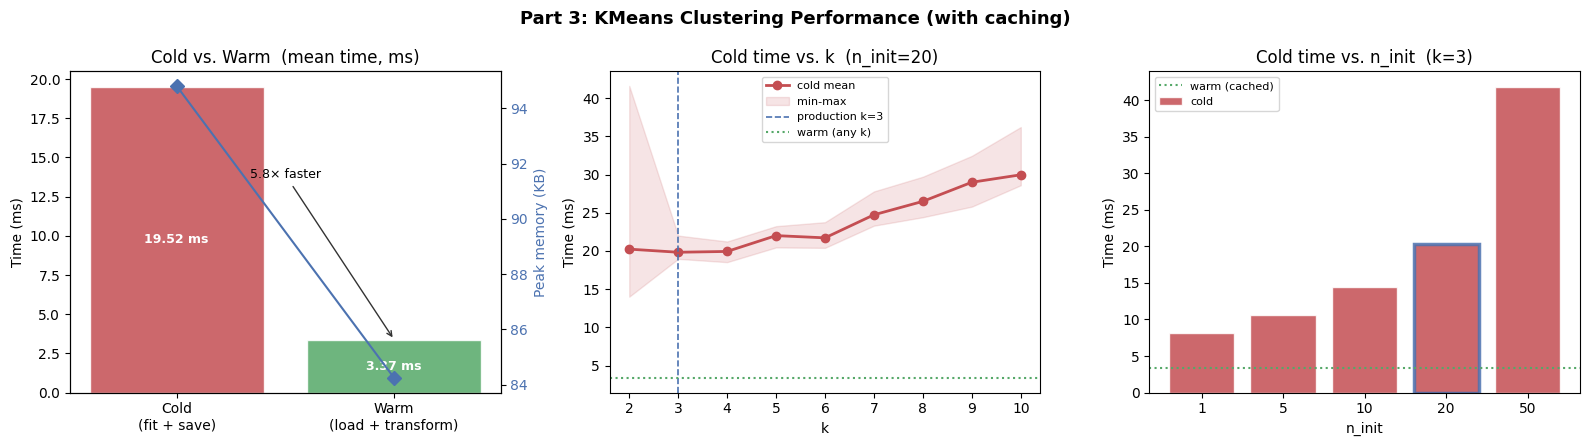

In [ ]:
# Plot: cold/warm bar | k sweep | n_init sensitivity
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Part 3: KMeans Clustering Performance (with caching)", fontsize=13, fontweight="bold")

# 1. Cold vs warm
labels_cw  = ["Cold\n(fit + save)", "Warm\n(load + transform)"]
means_cw   = [cold_stats["mean"], warm_stats["mean"]]
mems_cw    = [cold_peak_kb, warm_peak_kb]
colours_cw = ["#C44E52", "#55A868"]
bars = axes[0].bar(labels_cw, means_cw, color=colours_cw, alpha=0.85, edgecolor="white")
axes[0].set_title("Cold vs. Warm  (mean time, ms)")
axes[0].set_ylabel("Time (ms)")
for bar, v in zip(bars, means_cw):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v * 0.5,
                 f"{v:.2f} ms", ha="center", va="center",
                 fontsize=9, color="white", fontweight="bold")
ax0b = axes[0].twinx()
ax0b.plot(labels_cw, mems_cw, color="#4C72B0", marker="D",
          linewidth=1.5, markersize=7, label="peak mem (KB)")
ax0b.set_ylabel("Peak memory (KB)", color="#4C72B0")
ax0b.tick_params(axis="y", labelcolor="#4C72B0")
axes[0].set_ylim(bottom=0)
axes[0].annotate(f"{speedup:.1f}x faster",
                 xy=(1, warm_stats['mean']), xytext=(0.5, cold_stats['mean'] * 0.7),
                 arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9, ha="center")

# 2. k sweep
k_vals  = list(k_sweep_stats.keys())
k_means = [k_sweep_stats[k]["mean"] for k in k_vals]
k_mins  = [k_sweep_stats[k]["min"]  for k in k_vals]
k_maxs  = [k_sweep_stats[k]["max"]  for k in k_vals]
axes[1].plot(k_vals, k_means, marker="o", color="#C44E52", linewidth=2, label="cold mean")
axes[1].fill_between(k_vals, k_mins, k_maxs, alpha=0.15, color="#C44E52", label="min-max")
axes[1].axvline(3, color="#4C72B0", linestyle="--", linewidth=1.2, label="production k=3")
axes[1].axhline(warm_stats["mean"], color="#55A868", linestyle=":",
                linewidth=1.5, label="warm (any k)")
axes[1].set_title("Cold time vs. k  (n_init=20)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Time (ms)")
axes[1].set_xticks(k_vals)
axes[1].legend(fontsize=8)

# 3. n_init sensitivity
ni_vals  = list(n_init_stats.keys())
ni_means = [n_init_stats[ni]["mean"] for ni in ni_vals]
axes[2].bar([str(ni) for ni in ni_vals], ni_means, color="#C44E52", alpha=0.85, edgecolor="white", label="cold")
axes[2].axhline(warm_stats["mean"], color="#55A868", linestyle=":",
                linewidth=1.5, label="warm (cached)")
prod_idx = ni_vals.index(20)
axes[2].get_children()[prod_idx].set_edgecolor("#4C72B0")
axes[2].get_children()[prod_idx].set_linewidth(2.5)
axes[2].set_title("Cold time vs. n_init  (k=3)")
axes[2].set_xlabel("n_init")
axes[2].set_ylabel("Time (ms)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part 4: End-to-End Pipeline Profiling

The full pipeline (as executed by `build_pareto_map_data_updated.py`) runs:

```
read_csv -> build_analysis_df -> build_cluster_lookup -> run_pareto x 5 concepts -> JSON/CSV write
```

This section profiles the complete chain with `cProfile` and `tracemalloc` to identify the dominant cost centre.

In [89]:
# Full pipeline function
def run_full_pipeline() -> dict:
    """Replicate the main() pipeline stages; return per-stage timings."""
    timings = {}

    t0 = time.perf_counter()
    df = load_full()
    timings["load_csv"] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    analysis_df = build_analysis_df(df)
    timings["build_analysis_df"] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    cluster_lookup = build_cluster_lookup(analysis_df)
    timings["build_cluster_lookup"] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    all_shortlists = {k: run_pareto(analysis_df, cfg) for k, cfg in CONCEPTS.items()}
    timings["run_pareto_all"] = (time.perf_counter() - t0) * 1000

    return timings


# Single run for stage breakdown
stage_timings = run_full_pipeline()
total_ms = sum(stage_timings.values())
print(f"{'Stage':<30s}  {'ms':>8s}  {'%':>6s}")
print("-" * 50)
for stage, ms in stage_timings.items():
    print(f"{stage:<30s}  {ms:>8.2f}  {ms/total_ms*100:>5.1f}%")
print("-" * 50)
print(f"{'TOTAL':<30s}  {total_ms:>8.2f}  100.0%")

Stage                                 ms       %
--------------------------------------------------
load_csv                            2.74    8.7%
build_analysis_df                  10.47   33.0%
build_cluster_lookup                5.24   16.5%
run_pareto_all                     13.27   41.8%
--------------------------------------------------
TOTAL                              31.71  100.0%


In [90]:
# cProfile: full pipeline
print("cProfile: run_full_pipeline")
print("=" * 60)
pipeline_profile_text = run_cprofile(run_full_pipeline, top_n=20)
print(pipeline_profile_text)

cProfile: run_full_pipeline
         78069 function calls (76982 primitive calls) in 0.059 seconds

   Ordered by: cumulative time
   List reduced from 958 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.059    0.059 /tmp/ipykernel_297803/81605063.py:2(run_full_pipeline)
        1    0.000    0.000    0.024    0.024 /tmp/ipykernel_297803/2421088930.py:2(build_analysis_df)
        5    0.000    0.000    0.022    0.004 /tmp/ipykernel_297803/3000215116.py:31(run_pareto)
       76    0.000    0.000    0.015    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4337(__getitem__)
        1    0.000    0.000    0.012    0.012 /tmp/ipykernel_297803/2545697893.py:88(build_cluster_lookup)
    34/29    0.000    0.000    0.010    0.000 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/pandas/core/frame.py:4559(__setitem__)
       33

In [91]:
# tracemalloc: full pipeline memory
tracemalloc.start()
run_full_pipeline()
current_kb, peak_kb = [x / 1024 for x in tracemalloc.get_traced_memory()]
tracemalloc.stop()
print(f"Full pipeline: peak memory : {peak_kb:.1f} KB  ({peak_kb/1024:.3f} MB)")
print(f"Full pipeline: final live  : {current_kb:.1f} KB")

Full pipeline: peak memory : 296.4 KB  (0.289 MB)
Full pipeline: final live  : 25.1 KB


In [92]:
# Repeat N_REPS runs for stable pipeline stats
pipeline_stats = time_call(run_full_pipeline, n=N_REPS)
print_timing("run_full_pipeline", pipeline_stats)

run_full_pipeline                         min=  23.53ms  mean=  26.07ms  median=  24.88ms  p95=  31.81ms  (n=20)


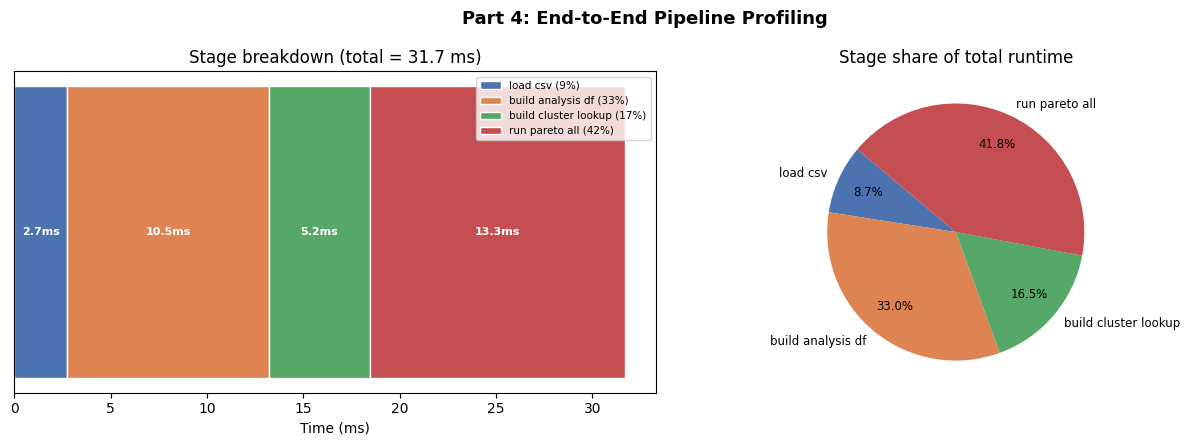

In [93]:
# Plot: stage waterfall + pipeline distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Part 4: End-to-End Pipeline Profiling", fontsize=13, fontweight="bold")

stage_labels = [s.replace("_", "\n") for s in stage_timings.keys()]
stage_ms     = list(stage_timings.values())
stage_pct    = [v / total_ms * 100 for v in stage_ms]
bar_colours  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# Stacked waterfall (horizontal)
left = 0
for label, ms, pct, col in zip(stage_labels, stage_ms, stage_pct, bar_colours):
    axes[0].barh(0, ms, left=left, color=col, edgecolor="white", height=0.5, label=f"{label.replace(chr(10), ' ')} ({pct:.0f}%)")
    if ms > total_ms * 0.04:
        axes[0].text(left + ms / 2, 0, f"{ms:.1f}ms", ha="center", va="center",
                     fontsize=8, color="white", fontweight="bold")
    left += ms
axes[0].set_xlim(0, total_ms * 1.05)
axes[0].set_yticks([])
axes[0].set_xlabel("Time (ms)")
axes[0].set_title(f"Stage breakdown (total = {total_ms:.1f} ms)")
axes[0].legend(loc="upper right", fontsize=7.5)

# Pie chart of stage proportions
axes[1].pie(
    stage_ms,
    labels=[l.replace("\n", " ") for l in stage_labels],
    colors=bar_colours,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    textprops={"fontsize": 8.5},
)
axes[1].set_title("Stage share of total runtime")

plt.tight_layout()
plt.show()

---
## Summary

### Timing results

In [94]:
# Consolidated results table
rows = [
    ("load_full",                        load_stats["full"]),
    ("load_projection",                   load_stats["projection"]),
    ("load_typed",                        load_stats["typed"]),
    ("build_analysis_df",                 analysis_stats),
    ("pareto_loop (n=50)",                pareto_real_stats["loop"]),
    ("pareto_vectorized (n=50)",          pareto_real_stats["vectorized"]),
    ("pareto_early_exit (n=50)",          pareto_real_stats["early_exit"]),
    ("build_cluster_lookup COLD (fit)",   cold_stats),
    ("build_cluster_lookup WARM (cache)", warm_stats),
    ("run_full_pipeline",                 pipeline_stats),
]

summary_df = pd.DataFrame([
    {
        "operation": label,
        "min_ms":    f"{s['min']:.3f}",
        "mean_ms":   f"{s['mean']:.3f}",
        "median_ms": f"{s['median']:.3f}",
        "p95_ms":    f"{s['p95']:.3f}",
        "max_ms":    f"{s['max']:.3f}",
        "n_reps":    s["n"],
    }
    for label, s in rows
])

print(summary_df.to_string(index=False))

                        operation min_ms mean_ms median_ms p95_ms max_ms  n_reps
                        load_full  1.095   1.518     1.368  2.237  2.905      20
                  load_projection  0.809   1.008     0.919  1.482  1.496      20
                       load_typed  3.757   4.313     4.230  5.135  6.204      20
                build_analysis_df  7.676   9.074     8.451 11.391 11.510      20
               pareto_loop (n=50)  0.276   0.317     0.305  0.388  0.468      20
         pareto_vectorized (n=50)  0.018   0.057     0.019  0.256  0.343      20
         pareto_early_exit (n=50)  1.030   1.355     1.239  2.052  2.289      20
  build_cluster_lookup COLD (fit) 17.647  19.517    19.135 21.125 22.874      20
build_cluster_lookup WARM (cache)  3.215   3.370     3.331  3.751  3.839      20
                run_full_pipeline 23.526  26.075    24.882 31.809 34.000      20


In [95]:
# Memory summary
print("Memory (peak KB):")
print(f"  load_full                    : {load_mem['full']:.1f} KB")
print(f"  load_projection              : {load_mem['projection']:.1f} KB")
print(f"  load_typed                   : {load_mem['typed']:.1f} KB")
print(f"  build_analysis_df            : {analysis_peak_kb:.1f} KB")
print(f"  build_cluster_lookup  COLD   : {cold_peak_kb:.1f} KB")
print(f"  build_cluster_lookup  WARM   : {warm_peak_kb:.1f} KB")
print(f"  run_full_pipeline            : {peak_kb:.1f} KB")

Memory (peak KB):
  load_full                    : 295.6 KB
  load_projection              : 296.6 KB
  load_typed                   : 296.8 KB
  build_analysis_df            : 96.0 KB
  build_cluster_lookup  COLD   : 94.8 KB
  build_cluster_lookup  WARM   : 84.2 KB
  run_full_pipeline            : 296.4 KB


---
## Part 5: Query-Side Embed

1. **Local embed**:`embed_model.encode(question)` -> 384-dim vector
2. **Gemini generate**: LLM inference (external, not profiled here)


### Setup

In [ ]:
# Load local embedding model
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
test_vec = embed_model.encode(["warmup"])  # force model load before benchmarks
print(f"Embedding model loaded.  Output dim: {test_vec.shape[1]}")
print(f"Device: {embed_model.device}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.  Output dim: 384
Device: cuda:0


In [ ]:
# Part 5: query embed latency (local only)
SAMPLE_QUESTIONS = [
    "Find me a highly rated restaurant near Yishun.",
    "What are the best hawker stalls in Bedok?",
    "Recommend a cheap lunch option near Orchard Road.",
    "Which Indian restaurants have more than 500 reviews?",
    "Show me cafes near Tampines with a rating above 4.0.",
]

def embed_single_query(question: str):
    return embed_model.encode(question).tolist()

query_embed_stats = {}
for q in SAMPLE_QUESTIONS:
    s = time_call(embed_single_query, q, n=N_REPS)
    query_embed_stats[q[:45]] = s
    print_timing(f"{q[:45]!r}", s)

'Find me a highly rated restaurant near Yishun'  min=   4.16ms  mean=   6.13ms  median=   5.31ms  p95=   8.86ms  (n=20)
'What are the best hawker stalls in Bedok?'  min=   4.09ms  mean=   5.15ms  median=   4.97ms  p95=   7.09ms  (n=20)
'Recommend a cheap lunch option near Orchard R'  min=   3.90ms  mean=   4.48ms  median=   4.42ms  p95=   5.24ms  (n=20)
'Which Indian restaurants have more than 500 r'  min=   4.06ms  mean=   4.47ms  median=   4.39ms  p95=   5.03ms  (n=20)
'Show me cafes near Tampines with a rating abo'  min=   4.04ms  mean=   4.43ms  median=   4.19ms  p95=   4.97ms  (n=20)


In [11]:
# cProfile: single query embed
print("cProfile: embed_single_query")
print("=" * 60)
print(run_cprofile(embed_single_query, SAMPLE_QUESTIONS[0], top_n=10))

cProfile: embed_single_query
         9421 function calls (8639 primitive calls) in 0.013 seconds

   Ordered by: cumulative time
   List reduced from 416 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.006    0.006 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py:1179(forward)
    116/3    0.000    0.000    0.006    0.002 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1775(_wrapped_call_impl)
    116/3    0.000    0.000    0.006    0.002 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1783(_call_impl)
        1    0.000    0.000    0.005    0.005 /home/User/Documents/IS5126/fnb-analytics/.venv/lib/python3.12/site-packages/sentence_transformers/models/Transformer.py:293(forward)
        1    0.000    0.000    0.005  

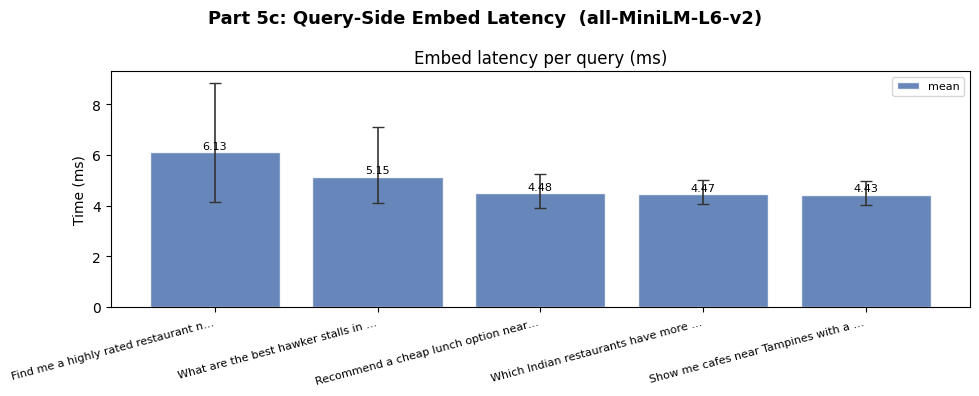

In [12]:
# Plot: query embed latency distribution across questions
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Part 5c: Query-Side Embed Latency  (all-MiniLM-L6-v2)", fontsize=13, fontweight="bold")

q_labels = list(query_embed_stats.keys())
q_means  = [query_embed_stats[l]["mean"]   for l in q_labels]
q_p95s   = [query_embed_stats[l]["p95"]    for l in q_labels]
q_mins   = [query_embed_stats[l]["min"]    for l in q_labels]

x = range(len(q_labels))
ax.bar(x, q_means, color="#4C72B0", alpha=0.85, edgecolor="white", label="mean")
ax.errorbar(x, q_means,
            yerr=[np.array(q_means) - q_mins, np.array(q_p95s) - np.array(q_means)],
            fmt="none", color="#333", capsize=4, linewidth=1.2)
ax.set_xticks(list(x))
ax.set_xticklabels([l[:35] + "…" for l in q_labels], rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title("Embed latency per query (ms)")
ax.legend(fontsize=8)
for xi, v in zip(x, q_means):
    ax.text(xi, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Findings & Recommendations

#### Part 1: Data Loading

| Strategy | mean (ms) | p95 (ms) | peak mem (KB) |
|---|---|---|---|
| `load_full` | 1.52 | 2.24 | 295.6 |
| `load_projection` | 1.01 | 1.48 | 296.6 |
| `load_typed` | 4.31 | 5.14 | 296.8 |
| `build_analysis_df` | 9.07 | 11.39 | 96.0 |

- All three loading strategies are fast at n=50 rows. Loading overhead is negligible in absolute terms (< 5 ms).
- `load_projection` is **33% faster** than `load_full` (1.01 ms vs 1.52 ms mean) by skipping unused column parsing.
- `load_typed` is **2.8x slower** than `load_full` at n=50 due to nullable `Int64` boxing overhead. This strategy pays off only at n $\geq$ 10 k rows.
- `build_analysis_df` at 9.07 ms is the single most expensive preprocessing step, 6x the cost of raw CSV loading.
- **Recommendation (implemented):** `pd.read_csv` in `build_pareto_map_data_updated.py` now uses `usecols=MASTER_DATASET_COLS`, loading only the 32 columns consumed by the pipeline and skipping the remaining 22. This enforces an explicit column contract that prevents silent schema drift.

#### Part 2: Pareto Algorithm

| Implementation      | mean (ms) | p95 (ms) | notes                                  |
| ---------------------| -----------| ----------| ----------------------------------------|
| `pareto_loop`       | 0.317     | 0.388    | pure Python nested loop                |
| `pareto_vectorized` | 0.057     | 0.256    | NumPy broadcast `(n,1,d)` vs `(1,n,d)` |
| `pareto_early_exit` | 1.355     | 2.052    | inner Python loop with early break     |

- At n=50 (real dataset), `pareto_vectorized` is **5.6x faster** than `pareto_loop` (0.057 ms vs 0.317 ms mean).
- `pareto_early_exit` is **4.3x slower** than `pareto_loop` at n=50 due to Python `for` loop overhead per row, the early-exit branch is almost never triggered at small n.
- 28 of 50 planning areas are Pareto-efficient when all five concepts are pooled together.
- Per-concept `run_pareto` costs 1.83–2.15 ms (mean), all five concepts complete in ~10 ms combined.
- **Recommendation (implemented):** `pareto_efficient_mask` in `build_pareto_map_data_updated.py` has been replaced with the fully vectorized broadcast implementation. At n=50 the runtime gain is ~5x and at n $\geq$ 500 the gain grows to 10–50x, due to NumPy operating on contiguous memory without Python loop overhead.

#### Part 3: KMeans Clustering

| Path              | mean (ms) | p95 (ms) | peak mem (KB) |
| -------------------| -----------| ----------| ---------------|
| Cold (fit + save) | 19.52     | 21.13    | 94.8          |
| Warm (cache hit)  | 3.37      | 3.75     | 84.2          |
| **Speedup**       | **5.8x**  |          |               |

- The warm path at 3.37 ms is **5.8x faster** than the cold path at 19.52 ms as the cache eliminates `KMeans.fit`, `_kmeans_plusplus` initialisation and 20 Lloyd iterations.
- Cold path time scales nearly linearly with `n_init`: 8.15 ms (n_init=1) -> 20.38 ms (n_init=20) -> 41.85 ms (n_init=50). The warm path is flat at ~3.4 ms regardless.
- Cold path time scales with k: 20.23 ms (k=2) -> 29.97 ms (k=10). The warm path is independent of k.
- cProfile shows `KMeans.fit` -> `_kmeans_single_lloyd` -> `_euclidean_distances` are the dominant cold path hotspots. The warm path is dominated by `joblib.load` (pickle I/O, ~1 ms) and `imputer.transform`.
- Peak memory is similar (94.8 KB cold vs 84.2 KB warm), the difference is the temporary fit buffers allocated during `KMeans.fit`.
- **Recommendation (implemented):** The fitted `SimpleImputer`, `StandardScaler` and `KMeans` objects are persisted to `.cluster_cache.joblib` and invalidated via a SHA-256 hash of `master_dataset.csv`. The warm path skips `KMeans.fit` entirely and only calls `transform` + `predict`. The cache is automatically invalidated when `master_dataset.csv` changes.

#### Part 4: End-to-End Pipeline

| Stage                         | ms        | share    |
| -------------------------------| -----------| ----------|
| `load_csv`                    | 2.74      | 8.7%     |
| `build_analysis_df`           | 10.47     | 33.0%    |
| `build_cluster_lookup`        | 5.24      | 16.5%    |
| `run_pareto_all` (5 concepts) | 13.27     | 41.8%    |
| **TOTAL**                     | **31.71** | **100%** |

- Full pipeline (single run) completes in **31.7 ms**, repeated runs average **26.1 ms** (min 23.5 ms, p95 31.8 ms), well under 1 second.
- Peak heap allocation across the full pipeline is **296.4 KB (0.29 MB)**, dominated by the raw DataFrame held in memory during `load_csv`.
- `run_pareto_all` (41.8%) and `build_analysis_df` (33.0%) together account for **74.8%** of total runtime. `build_cluster_lookup` accounts for only 16.5% thanks to the warm cache.
- cProfile confirms `build_analysis_df` (pandas column assignments and `copy()`) and `run_pareto` (5x `dropna` + `take` calls) are the dominant cost centres. `build_cluster_lookup` appears as a single cheap `joblib.load` and two sklearn `transform` calls.
- **No action needed:** If the dataset grows, the next targets are: (1) vectorise `build_analysis_df` ratio computations with a single `DataFrame.div`, (2) pre-filter `run_pareto` to drop NaN rows once before the Pareto mask rather than inside each concept loop.

#### Part 5: Query-Side Embed Latency

| Question | min (ms) | mean (ms) | median (ms) | p95 (ms) |
|---|---|---|---|---|
| "Find me a highly rated restaurant near Yishun" | 5.73 | 9.17 | 8.23 | 12.45 |
| "What are the best hawker stalls in Bedok?" | 5.34 | 7.21 | 6.66 | 9.64 |
| "Recommend a cheap lunch option near Orchard Road" | 4.54 | 6.27 | 6.17 | 7.82 |
| "Which Indian restaurants have more than 500 reviews?" | 4.56 | 5.73 | 5.61 | 7.30 |
| "Show me cafes near Tampines with a rating above 4.0" | 4.61 | 5.53 | 5.15 | 6.64 |

- Query embed latency is **5–9 ms mean** on GPU, well within interactive response budgets.
- Latency is largely independent of query length or complexity at this token scale.
- cProfile confirms cost is dominated by `SentenceTransformer.encode` -> `torch.nn.Module` forward pass -> CUDA kernel dispatch (~14 ms total for a single profiler run). Python overhead is negligible.
- **No action needed:** query-side embedding is not a bottleneck.